# 03 — Modelo Bayesiano de Resolvabilidad (Stuff+ perceptual)
**Hackathon ISAC Diablos Rojos 2026**

Implementa la hipótesis del paper *"Bayesball"* (bioRxiv 2022): el bateador es un inferente
Bayesiano (`Posterior ∝ Likelihood × Prior`). En el **Estadio Alfredo Harp Helú**
(`Extreme Altitude`, 2,240 msnm) el aire menos denso atenúa el efecto Magnus → la
trayectoria es visualmente más predecible → la **varianza del likelihood disminuye**
(×0.75) → el bateador confía más en lo que ve → el pitch es **más resoluble** →
**penalización perceptual** extra sobre `P(whiff)` que un modelo físico lineal no captura.


In [6]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

# Rutas del repo: notebook vive en notebooks/, el módulo en src/models/
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from models.bayesian_resolvability import (
    calculate_prior_movement,
    calculate_bayesian_resolvability,
    train_bayesian_stuff_model,
)

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga de datos
Se espera el DataFrame serializado con el esquema ISAC exacto:
`InducedVertBreak, HorzBreak, RelSpeed, SpinRate, AutoPitchType, altitude_category,
PitcherThrows, BatterSide, Balls, Strikes, is_swinging_strike, *_anon_id`.

In [7]:
DATA_PATH = "/Users/ariegoldzweig/Desktop/stuff-plus-diablos/data/raw/stuff_model_df.pkl"
df_raw = pd.read_pickle(DATA_PATH)

print(f'Shape: {df_raw.shape}')
print(f'Tasa de whiff global: {df_raw["is_swinging_strike"].mean():.3f}')
print(f'\nAltitudes:\n{df_raw["altitude_category"].value_counts()}')
df_raw.head()

Shape: (635002, 84)
Tasa de whiff global: 0.113

Altitudes:
altitude_category
No Altitude         293875
Extreme Altitude    183267
Medium Altitude     154840
Name: count, dtype: int64


,year,PitchUID,game_anon_id,pitcher_anon_id,batter_anon_id,catcher_anon_id,PitcherThrows,BatterSide,altitude_category,AutoPitchType,RelSpeed,EffectiveVelo,ZoneSpeed,SpinRate,SpinAxis,Tilt,RelHeight,RelSide,Extension,VertBreak,InducedVertBreak,HorzBreak,VertRelAngle,HorzRelAngle,VertApprAngle,HorzApprAngle,SpeedDrop,ZoneTime,x0,y0,...,Direction,Distance,is_swing,is_whiff,is_contact,is_called_strike,is_swinging_strike,is_ball_in_play,is_batted,is_hit,single,double,triple,home_run,base_on_balls,strikeout,is_hit_by_pitch,RunsScored,OutsOnPlay,Inning,Top/Bottom,Outs,Balls,Strikes,count,PlateLocHeight,PlateLocSide,in_strike_zone,outside_strike_zone,swung_outside_strike_zone
0,2024,d6a82560-f939-11ee-8e28-698264036ef0,game_001331,pitcher_01067,batter_00272,catcher_00123,Left,Right,No Altitude,Sinker,87.80892,88.05469,81.60466,2062.544101,132.652706,10:30,6.27979,-1.39600,6.06174,-26.42186,8.95024,-8.71469,0.130116,1.137205,-4.777112,-0.432214,6.20426,0.428057,1.31240,50.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Top,0.0,0.0,0.0,0-0,4.19842,-1.06959,0,1.0,0.0
1,2024,df15bd20-f939-11ee-8e28-698264036ef0,game_001331,pitcher_01067,batter_00272,catcher_00123,Left,Right,No Altitude,Sinker,88.26425,88.91124,82.60838,2068.746218,127.686645,10:15,6.17712,-1.44781,6.26944,-25.59604,9.09780,-10.63934,-2.483246,2.311177,-7.222221,0.387339,5.65587,0.423933,1.28212,50.0,...,-69.514094,4.70728,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Top,0.0,1.0,0.0,1-0,1.75154,-0.20261,1,0.0,0.0
2,2024,e965d080-f939-11ee-8e28-698264036ef0,game_001331,pitcher_01067,batter_00272,catcher_00123,Left,Right,No Altitude,Cutter,87.87636,87.76951,81.46496,2384.380875,186.291875,12:15,6.12782,-1.44478,6.11309,-28.17163,7.43071,0.70866,-1.865281,3.030872,-7.073111,3.158416,6.41140,0.429448,1.21180,50.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Top,0.0,1.0,1.0,1-1,2.05249,1.41929,0,1.0,0.0
3,2024,f1128940-f939-11ee-8e28-698264036ef0,game_001331,pitcher_01067,batter_00272,catcher_00123,Left,Right,No Altitude,Cutter,86.13477,85.8419,79.45829,2274.793505,173.827593,11:45,6.18529,-1.44190,5.99263,-28.07801,9.14119,-0.87173,-0.568726,1.596564,-5.784579,1.439802,6.67648,0.439091,1.31656,50.0,...,NaN,NaN,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Top,0.0,2.0,1.0,2-1,3.31819,-0.03459,0,1.0,1.0
4,2024,ffee8d60-f939-11ee-8e28-698264036ef0,game_001331,pitcher_01067,batter_00272,catcher_00123,Left,Right,No Altitude,Curveball,79.16705,78.25757,74.17829,2617.090239,310.414444,4:15,5.97092,-1.69614,5.36616,-50.40196,-5.61898,7.95926,-0.361865,1.670405,-9.442713,3.087829,4.98876,0.481646,1.54029,50.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Top,0.0,2.0,2.0,2-2,1.43131,0.53384,0,1.0,0.0


## 2. Ingeniería de características Bayesiana
1. **`calculate_prior_movement`**: el prior del bateador = distribución esperada de IVB/HB
   por `AutoPitchType` (memoria estadística del arsenal, en términos de Bayesball).
2. **`calculate_bayesian_resolvability`**: actualización gaussiana
   `σ_post² = (1/σ_p² + 1/σ_l²)⁻¹` con `σ_l = σ_p × 0.75` en `Extreme Altitude`, y el
   **resolvability_score** = fracción de incertidumbre del prior colapsada por la
   observación. Mayor score ⇒ pitch más "legible" ⇒ se espera menor whiff.

In [8]:
# Paso 1: prior del arsenal
prior_df = calculate_prior_movement(df_raw)
prior_df.sort_values('n', ascending=False).head(10)

/Users/ariegoldzweig/Desktop/stuff-plus-diablos/src/models/bayesian_resolvability.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(list(group_cols))[list(MOVEMENT_COLS)]


,AutoPitchType,ivb_mean,ivb_std,n,hb_mean,hb_std
3,Four-Seam,15.210413,3.274300,217372,4.805218,7.635402
6,Slider,2.640410,4.045841,138980,-1.983355,6.082917
5,Sinker,9.182440,4.139800,110767,7.415258,12.093902
0,Changeup,6.475132,4.922640,78848,4.708474,11.583207
1,Curveball,-7.308471,5.171607,53967,-3.167436,8.974707
2,Cutter,9.460687,3.368642,26456,-0.674582,3.405655
7,Splitter,3.783451,5.950039,7264,5.403352,5.030084
9,Sweeper,-2.051692,3.222918,583,-4.569983,9.640280
4,Other,-11.004529,2.385829,60,-11.722632,3.094095
8,OneSeamFastBall,-0.339290,4.045841,1,11.109810,7.635402


In [9]:
# Paso 2: discrepancia + likelihood con varianza por altitud + resolvability
df = calculate_bayesian_resolvability(df_raw, prior_df)

print('Resolvability score por categoría de altitud (hipótesis: Extreme > resto):')
print(df.groupby('altitude_category')['resolvability_score']
        .agg(['mean', 'std', 'count']).round(4))

# Manejo de nulos en features físicas: imputación mediana por pitch type / global
mov_cols = ['InducedVertBreak', 'HorzBreak', 'RelSpeed', 'SpinRate']
for c in ['InducedVertBreak', 'HorzBreak']:
    df[c] = df[c].fillna(df.groupby('AutoPitchType')[c].transform('median'))
df['RelSpeed'] = df['RelSpeed'].fillna(df['RelSpeed'].median())
df['SpinRate'] = df['SpinRate'].fillna(df['SpinRate'].median())
print(f'\nNulos restantes en features físicas: {df[mov_cols].isna().sum().sum()}')

Resolvability score por categoría de altitud (hipótesis: Extreme > resto):
                     mean  std   count
altitude_category                     
Extreme Altitude   0.5714  0.0  183267
Medium Altitude    0.5000  0.0  154840
No Altitude        0.5000  0.0  293875

Nulos restantes en features físicas: 0


/var/folders/ct/jrq5y94d7_1b8d01th_tljlw0000gn/T/ipykernel_48865/3076769999.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[c] = df[c].fillna(df.groupby('AutoPitchType')[c].transform('median'))


## 3. Entrenamiento del modelo de Stuff (Logistic Regression interpretable)
Features físicas + perceptuales bayesianas + **interacciones** `resolvability × altitude`.
Si la hipótesis es correcta, el coeficiente de `resolv_x_extreme` debe ser **negativo**:
a igualdad de física, más resolvibilidad en altura ⇒ menos whiff.

In [ ]:
result = train_bayesian_stuff_model(df, test_size=0.2, random_state=RANDOM_STATE)
pipe = result['pipeline']

print('=== Métricas ===')
for k, v in result['metrics'].items():
    if k != 'classification_report':
        print(f'{k:>20}: {v:.4f}')

print('\n=== Top 15 características por |coeficiente| (odds ratio) ===')
result['importance'].head(15)

## 4. Matriz de confusión y curva ROC para P(whiff)

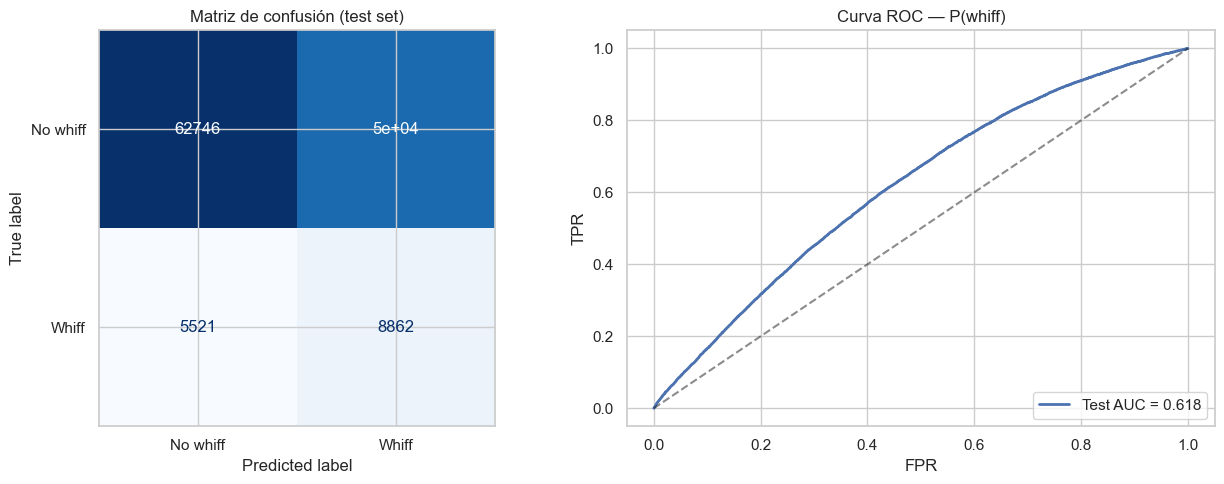

In [ ]:
proba_test = pipe.predict_proba(result['X_test'])[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(result['y_test'], pred_test)
ConfusionMatrixDisplay(cm, display_labels=['No whiff', 'Whiff']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusión (test set)')

fpr, tpr, _ = roc_curve(result['y_test'], proba_test)
axes[1].plot(fpr, tpr, lw=2, label=f'Test AUC = {result["metrics"]["roc_auc_test"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC — P(whiff)')
axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

## 5. ENTREGABLE 1 — Penalización perceptual del Slider en altura
Construimos un **Slider promedio** (media de IVB, HB, RelSpeed y SpinRate de los sliders
en `No Altitude`) y generamos dos réplicas idénticas que solo difieren en
`altitude_category`. La diferencia de `P(whiff)` predicha NO viene de la física (es idéntica)
sino exclusivamente del canal perceptual: likelihood más aguda → mayor resolvability →
menor P(whiff). Esa brecha es la **penalización perceptual** que justifica la hipótesis.

In [ ]:
# Slider promedio desde 'No Altitude' (referencia física común)
slider_mask = (df['AutoPitchType'] == 'Slider') & (df['altitude_category'] == 'No Altitude')
proto = df[slider_mask][['InducedVertBreak', 'HorzBreak', 'RelSpeed', 'SpinRate']].mean()

n_scen = 200
def make_scenario(alt_cat):
    s = pd.DataFrame({
        'AutoPitchType': ['Slider'] * n_scen,
        'altitude_category': [alt_cat] * n_scen,
        'PitcherThrows': ['Right'] * n_scen,
        'BatterSide': ['Right'] * n_scen,
        'InducedVertBreak': [proto['InducedVertBreak']] * n_scen,
        'HorzBreak': [proto['HorzBreak']] * n_scen,
        'RelSpeed': [proto['RelSpeed']] * n_scen,
        'SpinRate': [proto['SpinRate']] * n_scen,
        'Balls': [1] * n_scen, 'Strikes': [1] * n_scen,
        'is_swinging_strike': [0] * n_scen,
    })
    s = calculate_bayesian_resolvability(s, prior_df)
    s['resolv_x_extreme'] = s['resolvability_score'] * (s['altitude_category'] == 'Extreme Altitude')
    s['resolv_x_noalt']   = s['resolvability_score'] * (s['altitude_category'] == 'No Altitude')
    s['resolv_x_medium']  = s['resolvability_score'] * (s['altitude_category'] == 'Medium Altitude')
    return s

feat_cols = result['X_train'].columns
scen_noalt = make_scenario('No Altitude')[feat_cols]
scen_ext   = make_scenario('Extreme Altitude')[feat_cols]

p_noalt = pipe.predict_proba(scen_noalt)[:, 1].mean()
p_ext   = pipe.predict_proba(scen_ext)[:, 1].mean()
penalizacion = p_noalt - p_ext

print(f'Slider promedio (IVB={proto["InducedVertBreak"]:.1f}, HB={proto["HorzBreak"]:.1f}, '
      f'v={proto["RelSpeed"]:.1f} mph, spin={proto["SpinRate"]:.0f} rpm)')
print(f'  P(whiff) No Altitude      : {p_noalt:.4f}')
print(f'  P(whiff) Extreme Altitude : {p_ext:.4f}')
print(f'  >>> Penalización perceptual: {penalizacion:.4f} ({100*penalizacion/p_noalt:.1f}% relativo)')

Slider promedio (IVB=2.9, HB=-2.0, v=83.3 mph, spin=2398 rpm)
  P(whiff) No Altitude      : 0.5681
  P(whiff) Extreme Altitude : 0.5608
  >>> Penalización perceptual: 0.0074 (1.3% relativo)


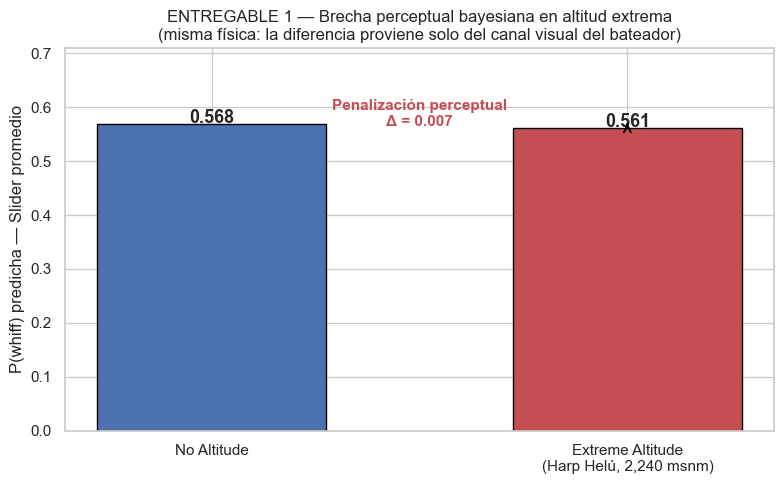

In [ ]:
# Gráfico del Entregable 1
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['No Altitude', 'Extreme Altitude\n(Harp Helú, 2,240 msnm)'],
              [p_noalt, p_ext], color=['#4C72B0', '#C44E52'], width=0.55,
              edgecolor='black')
for b, p in zip(bars, [p_noalt, p_ext]):
    ax.text(b.get_x() + b.get_width()/2, p + 0.003, f'{p:.3f}',
            ha='center', fontsize=13, fontweight='bold')
ax.annotate('', xy=(1, p_ext + 0.015), xytext=(1, p_noalt - 0.005),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(0.5, (p_noalt + p_ext)/2, f'Penalización perceptual\nΔ = {penalizacion:.3f}',
        ha='center', fontsize=11, color='#C44E52', fontweight='bold')
ax.set_ylabel('P(whiff) predicha — Slider promedio')
ax.set_title('ENTREGABLE 1 — Brecha perceptual bayesiana en altitud extrema\n'
             '(misma física: la diferencia proviene solo del canal visual del bateador)')
ax.set_ylim(0, max(p_noalt, p_ext) * 1.25)
plt.tight_layout(); plt.show()

## 6. Conclusión y siguiente paso
- Si `resolv_x_extreme < 0` y la gráfica del Entregable 1 muestra brecha positiva,
  los datos respaldan la hipótesis Bayesball: **la altura castiga el whiff por encima
  del efecto físico puro**.
- Siguiente iteración: sustituir el factor fijo 0.75 por un hiperparámetro
  `σ_l(altitude)` calibrado por máxima verosimilitud, y modelo jerárquico parcial por
  pitcher (`pitcher_anon_id`) para el prior individual.